In [1]:
import pandas as pd
import joblib
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()

,clean_text,label
0,target roe v wade oklahoma bill making felony ...,1
1,study woman drive time farther texas law close...,1
2,trump clinton clash dueling dc speech donald t...,1
3,grand jury texas indicts activist behind plann...,1
4,reproductive right hang balance debate moderat...,1


In [3]:
X = df["clean_text"]

y = df["label"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [6]:
models = {}

for file in os.listdir("../models"):

    if file.endswith(".pkl"):

        model_name = file.replace(".pkl","")

        models[model_name] = joblib.load(

            "../models/"+file

        )

In [7]:
models.keys()

dict_keys(['decision_tree', 'logistic_regression', 'naive_bayes', 'random_forest', 'svm'])

In [8]:
results = []

predictions = {}

for name, model in models.items():

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred
        )

    })

In [9]:
results = pd.DataFrame(results)

results = results.sort_values(

    by="Accuracy",

    ascending=False

)

results.reset_index(

    drop=True,

    inplace=True

)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,svm,0.946681,0.951542,0.941176,0.946331
1,logistic_regression,0.928183,0.947608,0.906318,0.926503
2,random_forest,0.905332,0.920814,0.886710,0.903441
3,naive_bayes,0.883569,0.880952,0.886710,0.883822
4,decision_tree,0.845484,0.866051,0.816993,0.840807


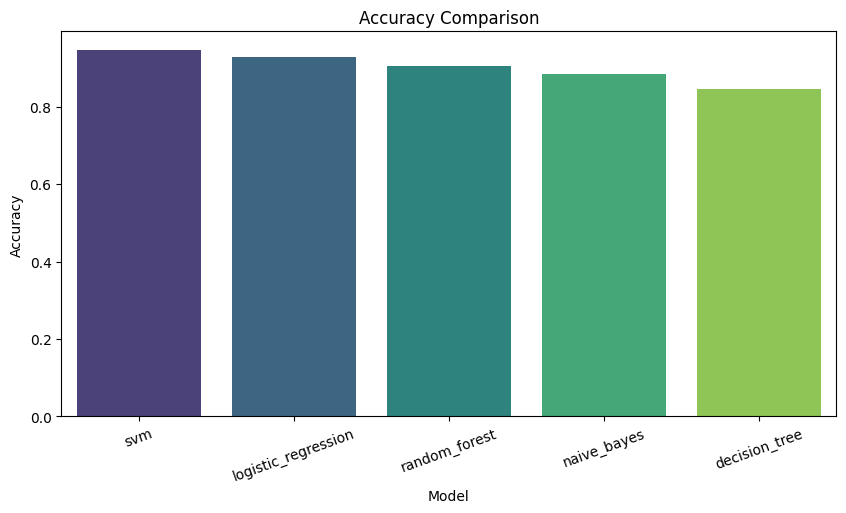

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Model",

    y="Accuracy",

    palette="viridis"

)

plt.title("Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

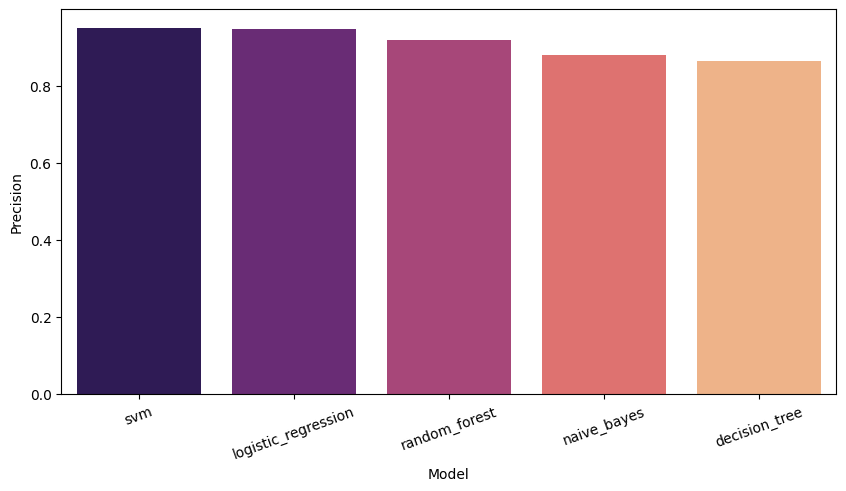

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Model",

    y="Precision",

    palette="magma"

)

plt.xticks(rotation=20)

plt.show()

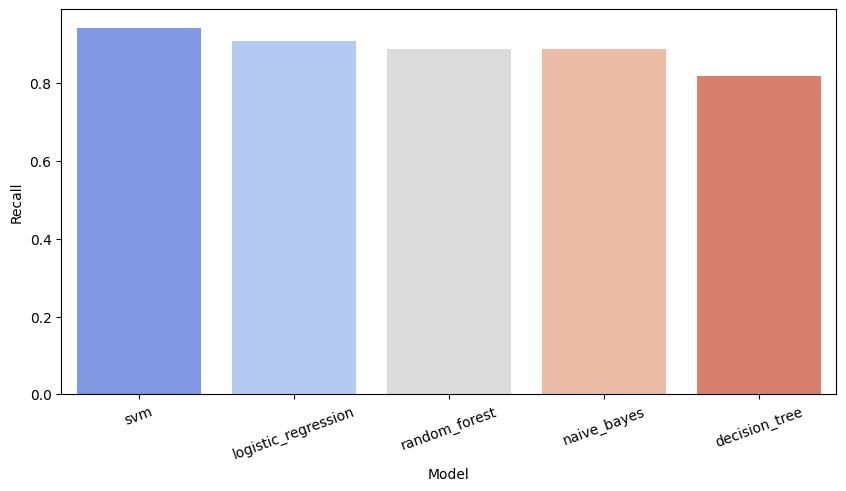

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Model",

    y="Recall",

    palette="coolwarm"

)

plt.xticks(rotation=20)

plt.show()

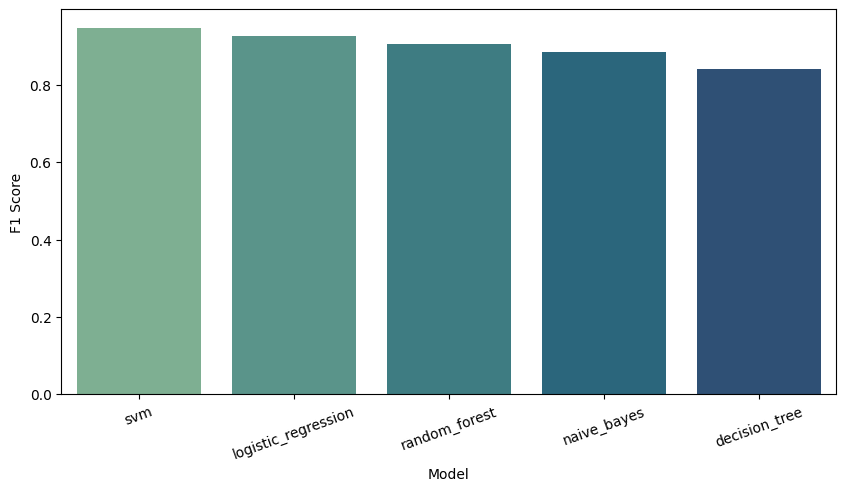

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Model",

    y="F1 Score",

    palette="crest"

)

plt.xticks(rotation=20)

plt.show()

In [14]:
best_model_name = results.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model :", best_model_name)

Best Model : svm


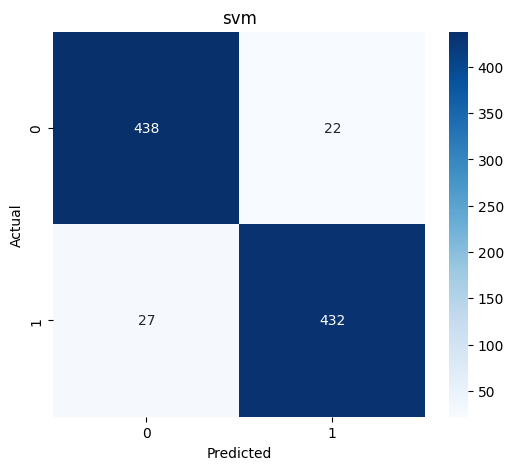

In [15]:
cm = confusion_matrix(

    y_test,

    predictions[best_model_name]

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(best_model_name)

plt.show()

In [16]:
print(

    classification_report(

        y_test,

        predictions[best_model_name]

    )

)

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       460
           1       0.95      0.94      0.95       459

    accuracy                           0.95       919
   macro avg       0.95      0.95      0.95       919
weighted avg       0.95      0.95      0.95       919



In [17]:
if hasattr(best_model, "predict_proba"):

    probability = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(

        y_test,

        probability

    )

    auc = roc_auc_score(

        y_test,

        probability

    )

    plt.figure(figsize=(6,6))

    plt.plot(

        fpr,

        tpr,

        label=f"AUC = {auc:.3f}"

    )

    plt.plot(

        [0,1],

        [0,1],

        "--"

    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

else:

    print("ROC Curve is not available for this model.")

ROC Curve is not available for this model.


In [18]:
if hasattr(best_model, "predict_proba"):

    precision, recall, _ = precision_recall_curve(

        y_test,

        probability

    )

    plt.figure(figsize=(6,6))

    plt.plot(

        recall,

        precision

    )

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title("Precision-Recall Curve")

    plt.show()

else:

    print("Precision-Recall Curve is not available.")

Precision-Recall Curve is not available.


In [19]:
results.to_csv(

    "../models/model_evaluation.csv",

    index=False

)

In [20]:
print("="*60)

print("Model Evaluation Completed")

print("="*60)

print(results)

print("="*60)

print("Best Model :", best_model_name)

Model Evaluation Completed
                 Model  Accuracy  Precision    Recall  F1 Score
0                  svm  0.946681   0.951542  0.941176  0.946331
1  logistic_regression  0.928183   0.947608  0.906318  0.926503
2        random_forest  0.905332   0.920814  0.886710  0.903441
3          naive_bayes  0.883569   0.880952  0.886710  0.883822
4        decision_tree  0.845484   0.866051  0.816993  0.840807
Best Model : svm
